# Cherimoya / CATv1 — chromatin accessibility across 1,518 ENCODE experiments

[Cherimoya](https://github.com/jmschrei/cherimoya) is a compact (~0.6 M parameter)
convolutional sequence-to-function model in the BPNet / ChromBPNet family. **CATv1**
— the Cherimoya Accessibility aTlas — is a family of 1,518 per-experiment models
covering **1,149 ENCODE DNase-seq and 369 ATAC-seq experiments** on GRCh38, each
trained across five chromosome-held-out folds.

That makes it the widest biosample coverage in chorus: ChromBPNet ships 42
ATAC/DNase models, Cherimoya ships 1,518. The trade is that each model is specific
to one experiment, so picking the right one matters — which is what most of this
notebook is about.

**Prerequisites**

```bash
chorus setup --oracle cherimoya      # ~7 GB env, ~3.5 min
chorus genome get hg38               # or symlink a GRCh38 FASTA to genomes/hg38.fa
```

Geometry is identical to ChromBPNet — 2,114 bp in, 1,000 bp out at base resolution —
so anything you already do with ChromBPNet transfers directly.


## 1. Setup


In [1]:
import chorus
import numpy

REFERENCE = "../../genomes/hg38.fa"   # adjust to your checkout

oracle = chorus.create_oracle(
    "cherimoya",
    use_environment=True,
    reference_fasta=REFERENCE,
)
print(oracle.list_assay_types())
print(f"{len(oracle.list_cell_types())} biosamples, {len(oracle.list_tracks())} tracks")


2026-08-09 17:21:38,063 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-08-09 17:21:43,767 - chorus.core.base - INFO - Using conda environment: chorus-cherimoya


['ATAC', 'DNASE']
407 biosamples, 1518 tracks


## 2. Finding the right track

Track ids are **`ASSAY:ENCSR`** — the ENCODE *experiment* accession — not
`ASSAY:cell_type`. That is a deliberate departure from ChromBPNet, and the reason is
worth understanding before you pick a model.

The 1,518 experiments collapse into only 492 `(assay, biosample)` pairs, and 162 of
those pairs hold more than one experiment — up to 83 for `DNase-seq / head of caudate
nucleus`. It is not confined to obscure tissues either: **K562 alone has four ATAC
experiments**. A biosample-keyed scheme would leave 1,188 of the 1,518 models
unaddressable.

So search, then choose.


In [2]:
hits = oracle.search_tracks("K562")
hits[["track_id", "assay", "biosample", "biosample_summary",
      "profile_pearson", "count_pearson"]]


,track_id,assay,biosample,biosample_summary,profile_pearson,count_pearson
80,ATAC:ENCSR859USB,ATAC,K562,NaN,0.63016,0.83833
449,DNASE:ENCSR000EOT,DNASE,K562,NaN,0.52701,0.72992
727,ATAC:ENCSR868FGK,ATAC,K562,NaN,0.85590,0.74361
1168,ATAC:ENCSR483RKN,ATAC,K562,NaN,0.67590,0.78842
1423,ATAC:ENCSR956DNB,ATAC,K562,NaN,0.63090,0.79979


`profile_pearson` and `count_pearson` are the model's fold-0 validation metrics, so
you can see up front how well a given experiment was learned. They vary a lot across
the atlas — worth checking before trusting a track.


## 3. Loading a model

Two ways in. The convenience path takes an assay and a biosample and resolves to a
**committed default** experiment for that pair; for ambiguous pairs it logs which one
it chose and how many alternatives exist.


In [3]:
oracle.load_pretrained_model(assay="DNASE", cell_type="K562")
print("resolved to:", oracle.track_id)

meta = oracle.describe_track(oracle.track_id)
print({k: meta[k] for k in ("biosample", "assay", "biosample_summary", "count_pearson")})


2026-08-09 17:21:44,233 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_0.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:44,482 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_1.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:44,738 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_2.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:44,977 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_3.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:45,219 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_4.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:45,221 - chorus.oracles.cherimoya - INFO - Loading Cherimoya DNASE:ENCSR000EOT (K562, 5-fold ensemble)...


2026-08-09 17:21:50,878 - chorus.oracles.cherimoya - INFO - Cherimoya model loaded in environment (cuda).


resolved to: DNASE:ENCSR000EOT
{'biosample': 'K562', 'assay': 'DNASE', 'biosample_summary': nan, 'count_pearson': 0.72992}


The nine pairs that ChromBPNet also covers are pinned to the CATv1 model trained on
the *same underlying ENCODE experiment*, so `ATAC:K562` means the same experiment on
both oracles and the two are directly comparable.

To pin any other experiment, pass `encode_id`:


In [4]:
oracle.load_pretrained_model(assay="ATAC", encode_id="ENCSR483RKN")
print("pinned:", oracle.track_id, "->", oracle.describe_track(oracle.track_id)["biosample"])


2026-08-09 17:21:51,134 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR483RKN/cherimoya.fold_0.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:51,387 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR483RKN/cherimoya.fold_1.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:51,633 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR483RKN/cherimoya.fold_2.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:51,925 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR483RKN/cherimoya.fold_3.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:52,172 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR483RKN/cherimoya.fold_4.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:52,173 - chorus.oracles.cherimoya - INFO - Loading Cherimoya ATAC:ENCSR483RKN (K562, 5-fold ensemble)...


2026-08-09 17:21:56,828 - chorus.oracles.cherimoya - INFO - Cherimoya model loaded in environment (cuda).


pinned: ATAC:ENCSR483RKN -> K562


## 4. Predicting


In [5]:
oracle.load_pretrained_model(assay="DNASE", cell_type="K562")

region = ("chr1", 1_000_000, 1_000_000 + oracle.sequence_length)
prediction = oracle.predict(region)
track = prediction[oracle.track_id]

print(f"track      : {oracle.track_id}")
print(f"values     : {len(track.values)} bp at {track.resolution} bp resolution")
print(f"total signal: {track.values.sum():.1f} predicted counts")


2026-08-09 17:21:57,077 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_0.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:57,378 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_1.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:57,621 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_2.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:57,856 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_3.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:58,093 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_4.torch "HTTP/1.1 302 Found"


2026-08-09 17:21:58,094 - chorus.oracles.cherimoya - INFO - Loading Cherimoya DNASE:ENCSR000EOT (K562, 5-fold ensemble)...


2026-08-09 17:22:02,750 - chorus.oracles.cherimoya - INFO - Cherimoya model loaded in environment (cuda).


track      : DNASE:ENCSR000EOT
values     : 2114 bp at 1 bp resolution
total signal: 2228.4 predicted counts


The model sees 2,114 bp and predicts the central 1,000 bp, so the flanks of the
returned array are zero by construction — the signal sits at the trim offset (557 bp).


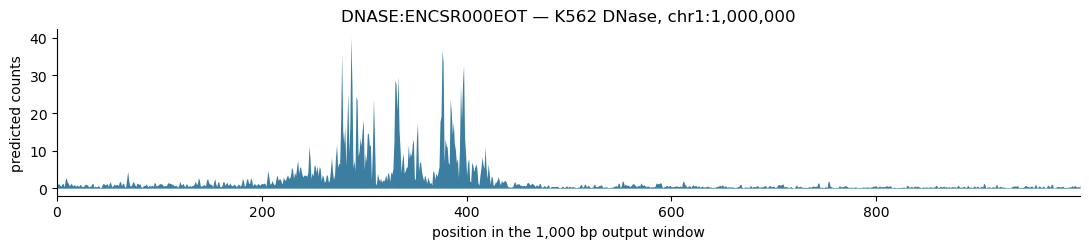

In [6]:
import matplotlib.pyplot as plt

TRIM = 557
profile = track.values[TRIM:TRIM + oracle.output_length]

fig, ax = plt.subplots(figsize=(11, 2.6))
ax.fill_between(range(len(profile)), profile, lw=0, color="#3b7ea1")
ax.set_xlabel("position in the 1,000 bp output window")
ax.set_ylabel("predicted counts")
ax.set_title(f"{oracle.track_id} — K562 DNase, chr1:1,000,000")
ax.spines[["top", "right"]].set_visible(False)
ax.margins(x=0)
plt.tight_layout()


## 5. Variant effects

`predict_variant_effect` runs the reference and alternate alleles through the model
and returns both predictions plus their difference.


In [7]:
position = 1_000_000 + oracle.sequence_length // 2

import pysam
with pysam.FastaFile(REFERENCE) as fasta:
    ref_base = fasta.fetch("chr1", position - 1, position).upper()
alt_base = "A" if ref_base != "A" else "G"
print(f"chr1:{position} {ref_base}>{alt_base}")

result = oracle.predict_variant_effect(
    genomic_region=f"chr1:{position}-{position}",
    variant_position=f"chr1:{position}",
    alleles=[ref_base, alt_base],
    assay_ids=None,
)


chr1:1001057 G>A


## 6. From raw fold-change to a percentile

A raw log2 fold-change is not interpretable on its own — a `+0.005` on a highly active
site and the same number on a dead one mean very different things. Chorus scores every
prediction against a per-track, genome-wide background so you get an **effect
percentile** (how unusual is this variant's effect on this track?) and an **activity
percentile** (how active is this site?).

The Cherimoya backgrounds are 1,518 per-track CDFs built from the same shared,
seeded variant and region sets the other oracles use, so the percentiles are
comparable across models.


In [8]:
from chorus.analysis.normalization import get_pertrack_normalizer
from chorus.analysis.scorers import score_variant_multilayer

normalizer = get_pertrack_normalizer("cherimoya")
row = score_variant_multilayer(result)["alt_1"][oracle.track_id]

effect = normalizer.effect_percentile("cherimoya", oracle.track_id, abs(row["raw_score"]))
activity = normalizer.activity_percentile("cherimoya", oracle.track_id, row["ref_value"])

print(f"layer            : {row['layer']}")
print(f"ref / alt        : {row['ref_value']:.1f} / {row['alt_value']:.1f}")
print(f"raw log2FC       : {row['raw_score']:+.4f}")
print(f"effect percentile: {effect:.3f}")
print(f"activity pctile  : {activity:.3f}")


2026-08-09 17:25:17,478 - chorus.analysis.normalization - INFO - Loaded per-track CDFs for 'cherimoya': 1518 tracks, CDFs: effect_cdfs, summary_cdfs, perbin_cdfs


layer            : chromatin_accessibility
ref / alt        : 1769.0 / 1765.8
raw log2FC       : -0.0026
effect percentile: 0.058
activity pctile  : 0.953


Read that as: a small effect, at a very active site. The raw number alone would not
have told you either half.

> If `get_pertrack_normalizer` finds nothing, the backgrounds are not on disk yet.
> See the oracle's section in [`docs/NORMALIZATION_GUIDE.md`](../../docs/NORMALIZATION_GUIDE.md)
> for where to fetch `cherimoya_pertrack.npz`.


## 7. Wide regions

For anything wider than the 2,114 bp input window, `predict_sliding` runs the model at
spaced offsets and stitches the central outputs into one continuous track covering
exactly the region you asked for.


3000 bp returned for a 3000 bp request


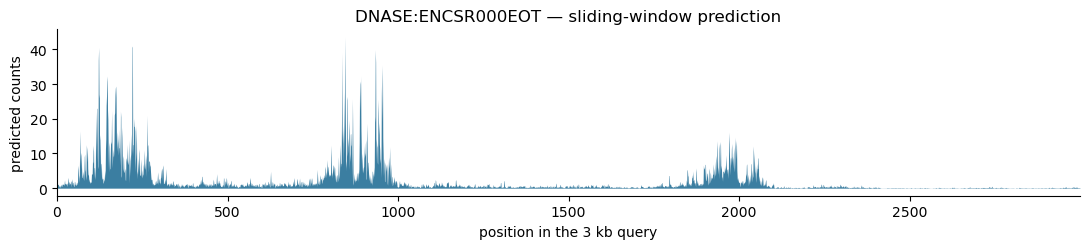

In [9]:
wide = ("chr1", 1_000_000, 1_003_000)
values = oracle.predict_sliding(wide)[oracle.track_id].values
print(f"{len(values)} bp returned for a {wide[2] - wide[1]} bp request")

fig, ax = plt.subplots(figsize=(11, 2.6))
ax.fill_between(range(len(values)), values, lw=0, color="#3b7ea1")
ax.set_xlabel("position in the 3 kb query")
ax.set_ylabel("predicted counts")
ax.set_title(f"{oracle.track_id} — sliding-window prediction")
ax.spines[["top", "right"]].set_visible(False)
ax.margins(x=0)
plt.tight_layout()


## 8. Comparing biosamples

The point of a 1,518-experiment atlas is asking where a locus is open. Because each
CATv1 model is one experiment, that means loading several in turn — cheap, since the
checkpoints are ~2.5 MB each.


In [10]:
targets = [
    ("DNASE", "K562"),
    ("DNASE", "GM12878"),
    ("DNASE", "HepG2"),
    ("DNASE", "H1"),
]

rows = []
for assay, biosample in targets:
    oracle.load_pretrained_model(assay=assay, cell_type=biosample)
    values = oracle.predict(region)[oracle.track_id].values
    centre = values[TRIM:TRIM + oracle.output_length]
    window = centre[250:751].sum()          # the 501 bp window chorus scores on
    pct = normalizer.activity_percentile("cherimoya", oracle.track_id, window)
    rows.append((biosample, oracle.track_id, window, pct))

for biosample, tid, window, pct in rows:
    print(f"{biosample:>9}  {tid:<20} {window:9.1f} counts   activity pctile {pct:.3f}")


2026-08-09 17:26:23,894 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_0.torch "HTTP/1.1 302 Found"


2026-08-09 17:26:24,138 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_1.torch "HTTP/1.1 302 Found"


2026-08-09 17:26:24,373 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_2.torch "HTTP/1.1 302 Found"


2026-08-09 17:26:24,618 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_3.torch "HTTP/1.1 302 Found"


2026-08-09 17:26:24,856 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EOT/cherimoya.fold_4.torch "HTTP/1.1 302 Found"


...

2026-08-09 17:29:46,640 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EMU/cherimoya.fold_3.torch "HTTP/1.1 302 Found"


2026-08-09 17:29:46,889 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/programmable-genomics/CATv1/resolve/main/models/ENCSR000EMU/cherimoya.fold_4.torch "HTTP/1.1 302 Found"


2026-08-09 17:29:46,891 - chorus.oracles.cherimoya - INFO - Loading Cherimoya DNASE:ENCSR000EMU (H1, 5-fold ensemble)...


2026-08-09 17:29:51,207 - chorus.oracles.cherimoya - INFO - Cherimoya model loaded in environment (cuda).


     K562  DNASE:ENCSR000EOT       1770.1 counts   activity pctile 0.953
  GM12878  DNASE:ENCSR000EMT        151.0 counts   activity pctile 0.944
    HepG2  DNASE:ENCSR149XIL        333.1 counts   activity pctile 0.914
       H1  DNASE:ENCSR000EMU         67.9 counts   activity pctile 0.951


The percentile is the column to read. Raw counts are not comparable across tracks —
sequencing depth and cell-type openness differ — but percentiles are, which is exactly
what the backgrounds are for.

---

## Notes and caveats

- **The 5-fold ensemble by default.** Each experiment has five chromosome-held-out
  folds. CATv1's model card offers either — "use a single fold (e.g. `fold_0`), or
  average the predictions of all five folds for a more robust estimate" — and chorus
  takes the second, because one checkpoint is a sample rather than the model: at
  rs12740374 the five folds give accessibility ratios spanning 2.39–3.47, and
  absolute reference counts spanning 2.49×, for the identical sequence. Pass
  `fold=0..4` to pin one. The background CDFs are built the same way, so the
  percentile ranks like against like.
- **GRCh38 only.** Unlike ChromBPNet, CATv1 ships no mouse models. The oracle warns
  if the reference does not look like hg38.
- **One experiment per instance.** A CATv1 model is specific to the experiment it was
  trained on; do not use it for a different biosample or assay.
- **Ambiguous pairs.** `(assay, cell_type)` resolves through a committed defaults
  table. If you care which experiment you get, pass `encode_id`.

Further reading: [Cherimoya](https://github.com/jmschrei/cherimoya) ·
[CATv1 on HuggingFace](https://huggingface.co/programmable-genomics/CATv1) ·
[`docs/NORMALIZATION_GUIDE.md`](../../docs/NORMALIZATION_GUIDE.md)
